# 📊 Pemodelan Prediktif & Evaluasi Model

Notebook ini adalah tahap **ke-4** (terakhir secara teknis) dari pipeline Data Science kita. Di tahap sebelumnya, kita sudah:
1. **Mengumpulkan data** — Scraping 684 ulasan dari toko Forebie di Shopee.
2. **Feature Engineering** — Menambahkan kolom `nama_produk`, `jumlah_kata`, `panjang_karakter`, dan `label_sentimen`.
3. **Text Preprocessing** — Membersihkan teks (case folding, hapus emoji, stopword removal, stemming) sehingga menghasilkan kolom `ulasan_bersih`.

**Sekarang, tujuan kita di notebook ini adalah:**
- Mengubah teks ulasan yang sudah bersih menjadi angka (vektor) agar bisa "dibaca" oleh algoritma Machine Learning.
- Melatih **3 algoritma klasifikasi** dan membandingkan mana yang paling bagus.
- Mengevaluasi model menggunakan metrik yang tepat (bukan cuma Accuracy!).
- Menyimpan model terbaik ke file agar bisa dipakai lagi tanpa training ulang.

---

### Mengapa Kita Butuh Machine Learning di Sini?

Bayangkan kamu punya 666 ulasan dan harus menentukan mana yang Positif, Netral, atau Negatif **satu per satu secara manual**. Capek banget, kan?

Dengan Machine Learning, kita "mengajari" komputer untuk mengenali pola dari teks ulasan. Setelah dilatih, komputer bisa **otomatis memprediksi** sentimen dari ulasan baru yang belum pernah dilihat sebelumnya.

**Analogi sederhana:** Seperti mengajari anak kecil membedakan kucing dan anjing. Kita tunjukkan banyak foto kucing dan anjing (data latih), lalu dia bisa mengenali sendiri foto baru yang belum pernah dilihat.

In [29]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
LABEL_NAMES = ["Negatif", "Netral", "Positif"]

---
## 1. Load Dataset Bersih

Kita memuat file `dataset_cleaned.csv` yang merupakan hasil akhir dari tahap preprocessing. File ini berisi kolom-kolom penting:

| Kolom | Penjelasan |
|---|---|
| `ulasan` | Teks ulasan asli dari pembeli |
| `ulasan_bersih` | Teks yang sudah dibersihkan (huruf kecil, tanpa emoji, sudah di-stem) |
| `label_sentimen` | Label teks: Negatif, Netral, atau Positif |
| `label_encoded` | Label dalam bentuk angka: 0 = Negatif, 1 = Netral, 2 = Positif |

Kolom `ulasan_bersih` adalah **input (X)** dan `label_encoded` adalah **target (y)** yang akan diprediksi oleh model.

In [30]:
df = pd.read_csv("../data/processed/dataset_cleaned.csv")
df = df.dropna(subset=["ulasan_bersih", "label_encoded"])
df["ulasan_bersih"] = df["ulasan_bersih"].astype(str)
df["label_encoded"] = df["label_encoded"].astype(int)

print(f"Total data: {len(df)}")
print(f"\nDistribusi Label Sentimen:")
print(df["label_sentimen"].value_counts())
print(f"\nContoh data:")
df[["ulasan_bersih", "label_sentimen", "label_encoded"]].head(3)

Total data: 666

Distribusi Label Sentimen:
label_sentimen
Positif    411
Netral     133
Negatif    122
Name: count, dtype: int64

Contoh data:


,ulasan_bersih,label_sentimen,label_encoded
0,produk barang rusak sorry to say perdana gue b...,Negatif,0
1,pertama kali make forebie beruntus jerawat mul...,Negatif,0
2,mungkin org cok kan aku ga ccok panas gatel je...,Negatif,0


---
## 2. Train / Test Split (80:20)

Sebelum melatih model, kita harus **membagi dataset menjadi dua bagian**:

- **Data Latih (Training Set) — 80%**: Digunakan untuk "mengajari" model mengenali pola.
- **Data Uji (Testing Set) — 20%**: Data yang **tidak pernah dilihat** model saat pelatihan. Digunakan untuk mengukur seberapa baik model bisa memprediksi data baru.

**Mengapa harus dipisah?** Kalau kita menguji model dengan data yang sama yang dipakai untuk melatihnya, hasilnya pasti bagus (seperti ujian buka buku pakai soal yang sama). Kita butuh data uji terpisah untuk mengetahui performa model yang **jujur** dan realistis.

Parameter `stratify=y` memastikan proporsi kelas (Positif/Netral/Negatif) di data latih dan data uji **tetap sama** dengan proporsi aslinya, sehingga tidak ada kelas yang hilang di salah satu set.

In [31]:
X = df["ulasan_bersih"]   # Input: teks ulasan
y = df["label_encoded"]    # Target: label sentimen (0, 1, 2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Latih : {len(X_train)} ulasan (80%)")
print(f"Data Uji   : {len(X_test)} ulasan (20%)")
print(f"\nDistribusi di Data Latih:")
print(y_train.value_counts().rename({0: 'Negatif', 1: 'Netral', 2: 'Positif'}))
print(f"\nDistribusi di Data Uji:")
print(y_test.value_counts().rename({0: 'Negatif', 1: 'Netral', 2: 'Positif'}))

Data Latih : 532 ulasan (80%)
Data Uji   : 134 ulasan (20%)

Distribusi di Data Latih:
label_encoded
Positif    328
Netral     106
Negatif     98
Name: count, dtype: int64

Distribusi di Data Uji:
label_encoded
Positif    83
Netral     27
Negatif    24
Name: count, dtype: int64


---
## 3. Ekstraksi Fitur Teks dengan TF-IDF

### Masalah: Komputer Tidak Bisa Membaca Teks!

Algoritma Machine Learning hanya bisa memproses **angka**, bukan teks. Jadi kita perlu cara untuk mengubah kalimat seperti *"produk bagus cocok kulit"* menjadi representasi numerik.

### Solusi: TF-IDF (Term Frequency — Inverse Document Frequency)

TF-IDF adalah teknik yang memberikan **skor penting** pada setiap kata dalam dokumen:

- **TF (Term Frequency)**: Seberapa sering kata muncul di satu ulasan. Kata yang sering muncul di ulasan tertentu dianggap penting untuk ulasan itu.
- **IDF (Inverse Document Frequency)**: Seberapa unik kata tersebut di seluruh dataset. Kata yang muncul di **semua** ulasan (seperti "yang", "dan") mendapat skor rendah karena tidak informatif.

**Contoh sederhana:**
- Kata *"jerawat"* muncul banyak di ulasan negatif → skor TF-IDF tinggi di ulasan negatif.
- Kata *"bagus"* muncul banyak di ulasan positif → skor TF-IDF tinggi di ulasan positif.
- Kata *"produk"* muncul di hampir semua ulasan → skor IDF rendah, tidak terlalu berguna.

### Parameter TF-IDF yang kita gunakan:
| Parameter | Nilai | Penjelasan |
|---|---|---|
| `max_features` | 5000 | Ambil maksimal 5000 kata/frasa terpenting |
| `ngram_range` | (1, 2) | Tangkap kata tunggal DAN pasangan kata (bigram) seperti *"tidak cocok"* |
| `min_df` | 2 | Abaikan kata yang muncul di kurang dari 2 dokumen |
| `max_df` | 0.95 | Abaikan kata yang muncul di lebih dari 95% dokumen |

In [32]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigram + bigram
    min_df=2,
    max_df=0.95,
)

# fit_transform pada data latih, transform saja pada data uji
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensi matriks TF-IDF data latih : {X_train_tfidf.shape}")
print(f"Dimensi matriks TF-IDF data uji   : {X_test_tfidf.shape}")
print(f"\nArtinya: setiap ulasan direpresentasikan oleh {X_train_tfidf.shape[1]} fitur numerik.")
print(f"\nContoh 10 fitur (kata/bigram) pertama:")
print(list(vectorizer.get_feature_names_out()[:10]))

Dimensi matriks TF-IDF data latih : (532, 2566)
Dimensi matriks TF-IDF data uji   : (134, 2566)

Artinya: setiap ulasan direpresentasikan oleh 2566 fitur numerik.

Contoh 10 fitur (kata/bigram) pertama:
['aaa', 'aaaa', 'aamiin', 'abis', 'abis pake', 'acid', 'acne', 'acne fighter', 'acne prone', 'acne serum']


---
## 4. Pelatihan & Evaluasi 3 Model Klasifikasi

Kita akan membandingkan **3 algoritma** yang umum digunakan untuk klasifikasi teks:

### A. SVM (Support Vector Machine) — LinearSVC
SVM bekerja dengan mencari **garis batas (hyperplane)** terbaik yang memisahkan kelas-kelas data. Bayangkan kamu punya titik-titik merah (Negatif) dan biru (Positif) di sebuah bidang. SVM mencari garis yang memisahkan keduanya dengan **jarak terlebar** (margin terbesar). LinearSVC adalah versi SVM yang efisien untuk data berdimensi tinggi seperti TF-IDF.

### B. Naive Bayes (MultinomialNB)
Naive Bayes menggunakan **teori probabilitas**. Ia menghitung: *"Jika ada kata 'jerawat' dan 'parah' dalam ulasan, berapa peluang ulasan ini Negatif?"*. Disebut "naive" (naif) karena mengasumsikan setiap kata **independen** satu sama lain (padahal di dunia nyata tidak selalu begitu). Meskipun sederhana, Naive Bayes sering bekerja cukup baik untuk klasifikasi teks.

### C. Logistic Regression
Meskipun namanya "Regression", algoritma ini sebenarnya digunakan untuk **klasifikasi**. Ia menghitung probabilitas sebuah ulasan termasuk kelas tertentu menggunakan fungsi logistik (sigmoid). Logistic Regression sangat populer karena cepat, mudah diinterpretasi, dan performanya sering kompetitif.

---

### Penanganan Class Imbalance: `class_weight='balanced'`

Dataset kita **tidak seimbang**: Positif (62%), Netral (20%), Negatif (18%). Tanpa penanganan, model akan cenderung memprediksi semua ulasan sebagai Positif (karena itu cara termudah untuk mendapat akurasi tinggi).

Parameter `class_weight='balanced'` memberikan **bobot lebih tinggi** pada kelas minoritas (Negatif & Netral), sehingga model "dipaksa" untuk lebih memperhatikan kelas-kelas yang jumlahnya sedikit. Ini seperti memberi nilai lebih pada soal yang sulit di ujian.

In [33]:
models = {
    "SVM (LinearSVC)": LinearSVC(
        class_weight="balanced", max_iter=10000, random_state=42
    ),
    "Naive Bayes": MultinomialNB(alpha=1.0),
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
}

results = {}

for name, model in models.items():
    # Latih model
    model.fit(X_train_tfidf, y_train)
    
    # Prediksi pada data uji
    y_pred = model.predict(X_test_tfidf)

    # Hitung metrik evaluasi
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    report = classification_report(y_test, y_pred, target_names=LABEL_NAMES)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "model": model, "accuracy": acc, "f1_score": f1,
        "report": report, "confusion_matrix": cm, "y_pred": y_pred
    }

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"{'='*55}")
    print(report)


  Model: SVM (LinearSVC)
  Accuracy : 0.7388
  F1-Score : 0.7268
              precision    recall  f1-score   support

     Negatif       0.79      0.62      0.70        24
      Netral       0.48      0.37      0.42        27
     Positif       0.79      0.89      0.84        83

    accuracy                           0.74       134
   macro avg       0.68      0.63      0.65       134
weighted avg       0.72      0.74      0.73       134


  Model: Naive Bayes
  Accuracy : 0.7090
  F1-Score : 0.6496
              precision    recall  f1-score   support

     Negatif       1.00      0.46      0.63        24
      Netral       0.60      0.11      0.19        27
     Positif       0.69      0.98      0.81        83

    accuracy                           0.71       134
   macro avg       0.76      0.52      0.54       134
weighted avg       0.73      0.71      0.65       134


  Model: Logistic Regression
  Accuracy : 0.7313
  F1-Score : 0.7316
              precision    recall  f1-sc

---
## 5. Memahami Metrik Evaluasi

Sebelum melihat hasil visualisasi, penting untuk memahami **apa arti angka-angka di atas**:

### Accuracy
Persentase prediksi yang benar dari **total semua prediksi**. Contoh: Accuracy 0.74 berarti 74 dari 100 ulasan diprediksi dengan benar.

> ⚠️ **Kenapa Accuracy saja tidak cukup?** Karena data kita tidak seimbang! Jika model memprediksi SEMUA ulasan sebagai Positif, accuracy-nya sudah 62% (karena 62% data memang Positif). Tapi model seperti itu **sama sekali tidak berguna** untuk mendeteksi ulasan Negatif.

### Precision
Dari semua ulasan yang **diprediksi** sebagai kelas X, berapa persen yang **benar-benar** kelas X?
- Contoh: Precision Negatif = 0.83 → Dari semua ulasan yang model bilang "Negatif", 83% memang benar Negatif.

### Recall
Dari semua ulasan yang **sebenarnya** kelas X, berapa persen yang **berhasil ditemukan** oleh model?
- Contoh: Recall Negatif = 0.62 → Dari 24 ulasan Negatif di data uji, model berhasil mendeteksi 62%-nya (sisanya salah diprediksi sebagai Netral/Positif).

### F1-Score
**Rata-rata harmonis** dari Precision dan Recall. F1-Score memberikan gambaran yang **seimbang** tentang performa model, terutama ketika data tidak seimbang. Inilah metrik utama yang kita gunakan untuk memilih model terbaik.

---

## 6. Perbandingan Visual Performa Model

Grafik batang berikut membandingkan Accuracy dan F1-Score dari ketiga model secara berdampingan, sehingga kita bisa langsung melihat mana yang paling unggul.

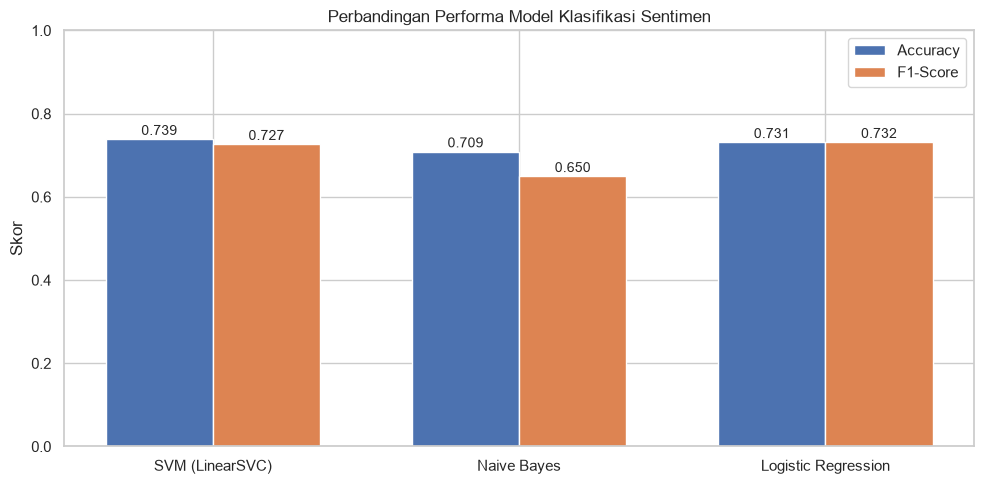

In [34]:
model_names = list(results.keys())
accuracies = [results[m]["accuracy"] for m in model_names]
f1_scores = [results[m]["f1_score"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#DD8452')

ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Model Klasifikasi Sentimen')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Confusion Matrix — Apa Itu dan Bagaimana Membacanya?

Confusion Matrix adalah tabel yang menunjukkan **detail kesalahan** model. Ini jauh lebih informatif daripada sekadar angka Accuracy.

**Cara membacanya:**
- **Baris** = Label sebenarnya (ground truth)
- **Kolom** = Prediksi model
- **Diagonal** (kiri atas ke kanan bawah) = Prediksi yang **benar**
- **Di luar diagonal** = Prediksi yang **salah**

Contoh: Jika di baris "Negatif" kolom "Positif" ada angka 5, berarti ada **5 ulasan Negatif yang salah diprediksi sebagai Positif** oleh model.

### 7.1 Confusion Matrix — Model Terbaik

🏆 Model terbaik: Logistic Regression
   Accuracy : 0.7313
   F1-Score : 0.7316


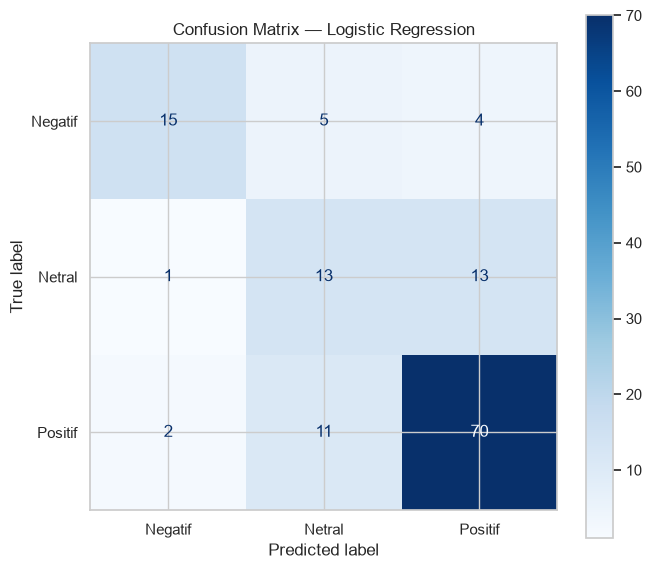

In [35]:
# Pilih model terbaik berdasarkan F1-Score
best_name = max(results, key=lambda k: results[k]["f1_score"])
best_result = results[best_name]

print(f"🏆 Model terbaik: {best_name}")
print(f"   Accuracy : {best_result['accuracy']:.4f}")
print(f"   F1-Score : {best_result['f1_score']:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=best_result["confusion_matrix"],
    display_labels=LABEL_NAMES
)
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

### 7.2 Confusion Matrix — Perbandingan Semua Model

Berikut confusion matrix ketiga model ditampilkan berdampingan agar mudah dibandingkan. Model terbaik ditandai dengan simbol bintang (★).

C:\Users\LOQ\AppData\Local\Temp\ipykernel_15212\382932405.py:12: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Lindan\Cool\ds\uas\shopee-sentiment-analysis\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


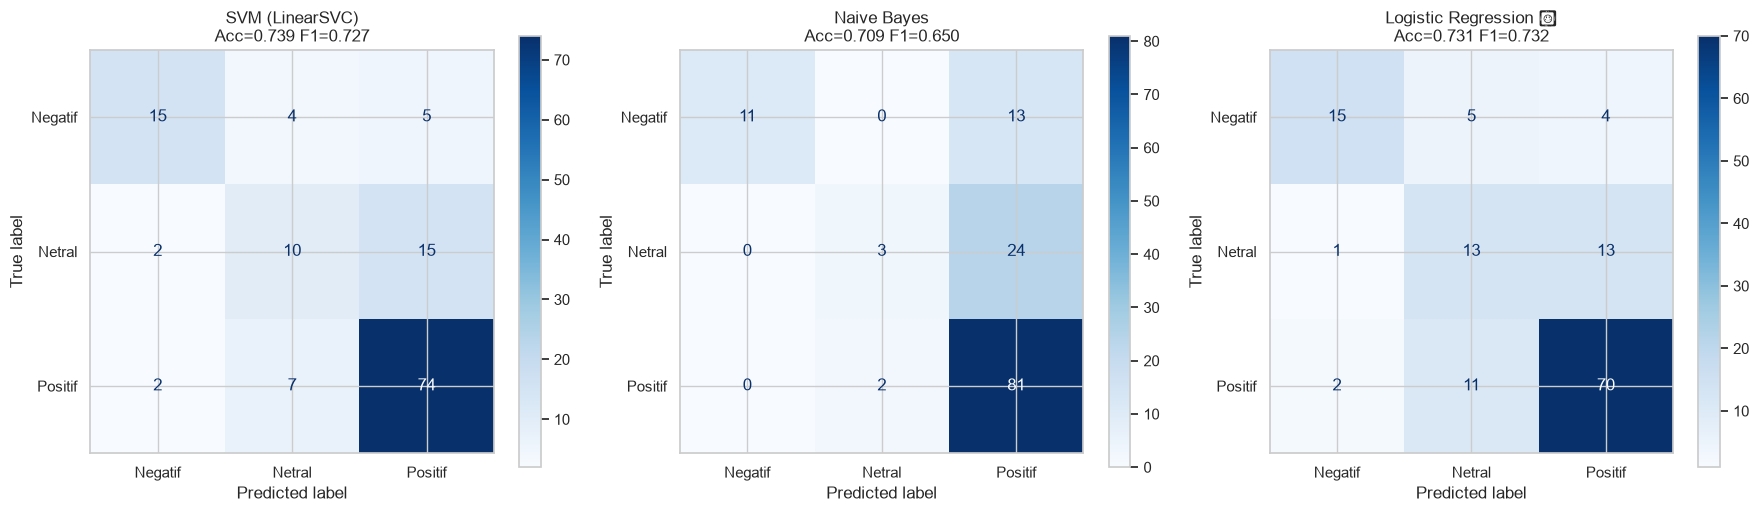

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res["confusion_matrix"],
        display_labels=LABEL_NAMES
    )
    disp.plot(cmap="Blues", ax=ax, values_format="d")
    marker = " ★" if name == best_name else ""
    ax.set_title(f"{name}{marker}\nAcc={res['accuracy']:.3f} F1={res['f1_score']:.3f}")

plt.tight_layout()
plt.show()

---
## 8. Analisis Hasil & Kesimpulan Pemilihan Model

### Ringkasan Performa:

| Model | Accuracy | F1-Score | Kelebihan | Kekurangan |
|---|---|---|---|---|
| SVM (LinearSVC) | 0.739 | 0.727 | Accuracy tertinggi | F1 sedikit di bawah LR |
| Naive Bayes | 0.709 | 0.650 | Precision Negatif sempurna (1.00) | Recall Netral sangat rendah (0.11) |
| **Logistic Regression** | **0.731** | **0.732** | **F1-Score tertinggi, paling seimbang** | Precision Netral rendah |

### Mengapa Logistic Regression Dipilih sebagai Model Terbaik?

1. **F1-Score tertinggi (0.732)**: F1-Score adalah metrik yang paling relevan untuk dataset yang tidak seimbang seperti milik kita, karena memperhitungkan keseimbangan antara Precision dan Recall.

2. **Performa paling seimbang antar-kelas**: Logistic Regression memberikan Recall yang lebih merata di ketiga kelas dibanding model lain. Naive Bayes misalnya, meskipun Precision Negatifnya sempurna (1.00), Recall Netral-nya hanya 0.11 (artinya hanya 11% ulasan Netral yang berhasil dideteksi — sangat buruk!).

3. **Interpretabilitas tinggi**: Logistic Regression memungkinkan kita melihat kata-kata mana yang paling berpengaruh terhadap prediksi (melalui bobot/koefisien), sehingga hasilnya lebih mudah dijelaskan.

### Catatan Penting:
Kelas **Netral** (F1 = 0.46) memang sulit diprediksi oleh semua model. Ini wajar karena ulasan rating 3 seringkali ambigu — isinya bisa terdengar positif (*"bagus sih tapi..."*) atau negatif (*"lumayan, cuma kurang..."*). Dalam dunia NLP, kelas "netral" memang selalu menjadi tantangan terbesar.

---
## 9. Simpan Model Terbaik (Model Persistence / File I/O)

Kita menyimpan model terbaik dan TF-IDF Vectorizer ke dalam file `.joblib` agar:
- **Tidak perlu training ulang** setiap kali ingin melakukan prediksi.
- Model bisa digunakan di **aplikasi lain** (misalnya web app atau API).
- Memenuhi syarat tugas: *"Simpan model terbaik yang telah dilatih ke dalam file .pkl atau .joblib menggunakan teknik File I/O."*

**Mengapa TF-IDF Vectorizer juga harus disimpan?** Karena saat memprediksi ulasan baru, kita harus mengubah teksnya menjadi vektor TF-IDF dengan **kamus kata yang sama** persis seperti saat training. Kalau kita membuat vectorizer baru, kamus katanya akan berbeda dan model tidak bisa bekerja.

In [37]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "best_model.joblib"
vectorizer_path = models_dir / "tfidf_vectorizer.joblib"

joblib.dump(best_result["model"], model_path)
joblib.dump(vectorizer, vectorizer_path)

print(f"✅ Model '{best_name}' disimpan ke: {model_path}")
print(f"✅ TF-IDF Vectorizer disimpan ke  : {vectorizer_path}")
print(f"\nUkuran file model     : {model_path.stat().st_size / 1024:.1f} KB")
print(f"Ukuran file vectorizer: {vectorizer_path.stat().st_size / 1024:.1f} KB")

✅ Model 'Logistic Regression' disimpan ke: ..\models\best_model.joblib
✅ TF-IDF Vectorizer disimpan ke  : ..\models\tfidf_vectorizer.joblib

Ukuran file model     : 61.0 KB
Ukuran file vectorizer: 97.7 KB


---
## 10. Demo Prediksi Sentimen pada Ulasan Baru

Untuk membuktikan bahwa model yang sudah disimpan **benar-benar bekerja**, kita akan:
1. Memuat kembali model dan vectorizer dari file `.joblib`.
2. Memberikan beberapa contoh ulasan baru yang **belum pernah dilihat** model.
3. Melihat apakah prediksinya masuk akal.

Ini juga menunjukkan bagaimana model bisa diintegrasikan ke aplikasi nyata di masa depan.

In [38]:
# Load model yang sudah disimpan
loaded_model = joblib.load(model_path)
loaded_vectorizer = joblib.load(vectorizer_path)

# Contoh ulasan baru (belum pernah dilihat model)
contoh_ulasan = [
    "produk bagus banget cocok di kulit aku",
    "tidak cocok malah bikin jerawat makin parah",
    "lumayan sih tapi pengiriman lama",
    "barang rusak kemasan bocor kecewa banget",
    "suka banget repurchase terus",
]

# Transformasi teks ke vektor TF-IDF
X_demo = loaded_vectorizer.transform(contoh_ulasan)

# Prediksi sentimen
predictions = loaded_model.predict(X_demo)

print("🔮 Demo Prediksi Sentimen Ulasan Baru")
print("=" * 60)
for text, pred in zip(contoh_ulasan, predictions):
    emoji_map = {0: "😠", 1: "😐", 2: "😊"}
    print(f"  {emoji_map[pred]} Ulasan  : \"{text}\"")
    print(f"     Prediksi: {LABEL_NAMES[pred]}")
    print()

🔮 Demo Prediksi Sentimen Ulasan Baru
  😊 Ulasan  : "produk bagus banget cocok di kulit aku"
     Prediksi: Positif

  😠 Ulasan  : "tidak cocok malah bikin jerawat makin parah"
     Prediksi: Negatif

  😐 Ulasan  : "lumayan sih tapi pengiriman lama"
     Prediksi: Netral

  😠 Ulasan  : "barang rusak kemasan bocor kecewa banget"
     Prediksi: Negatif

  😊 Ulasan  : "suka banget repurchase terus"
     Prediksi: Positif

